# Meshing

This notebook is used to develop the meshing tools necessary for this project. The components of this task are as follows.

- Efficiently read in a fort.14 file
- Filter the mesh to the sub-region of interest.
- Preserve boundary segments for use in the FEniCSx solver.

In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
import adcircxtools as at
import basix.ufl
import dolfinx as dx
import dolfinx.plot
from mpi4py import MPI
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri
import pyvista as pv
import scipy.interpolate
import scipy.spatial
import ufl

## Read in fort.14

In [27]:
adcirc_mesh = at.mesh.ADCIRCMesh.from_fort_14('120m_cut.14')
mesh = at.mesh.Mesh.from_ADCIRCMesh(adcirc_mesh)

## Filter to desired subregion

In [28]:
# The center of a circular filter
# Location of Port Aransas
pa_lon = -97.0611 # deg
pa_lat = 27.8339 # deg
radius_earth = 6371.0 # km
arcradius_main = 10.0 # km
arcradius_interp = arcradius_main + 2.0 # km, for dp/eta/v

In [29]:
# Define a filter callable
filter_main = lambda lon, lat: np.deg2rad(at.geometry.central_angle(
    pa_lon,
    pa_lat,
    lon,
    lat,
    use_deg=True
)) * radius_earth < arcradius_main

In [30]:
# Filter nodes within certain arclength of PA
mesh_main, node_map_main, element_map_main = mesh.filter_by_coordinates(filter_main)

In [31]:
# Define triangulation for interpolation and visualization
triangulation_main = matplotlib.tri.Triangulation(
    mesh_main.coordinates[:, 0],
    mesh_main.coordinates[:, 1],
    mesh_main.elements
)

In [32]:
# Define a filter callable
filter_interp = lambda lon, lat: np.deg2rad(at.geometry.central_angle(
    pa_lon,
    pa_lat,
    lon,
    lat,
    use_deg=True
)) * radius_earth < arcradius_interp

In [33]:
# Filter nodes within certain arclength of PA
mesh_interp, node_map_interp, element_map_interp = mesh.filter_by_coordinates(filter_interp)

In [34]:
# Define triangulation for interpolation and visualization
triangulation_interp = matplotlib.tri.Triangulation(
    mesh_interp.coordinates[:, 0],
    mesh_interp.coordinates[:, 1],
    mesh_interp.elements
)

/var/folders/nc/8r3mn3bn43b7lyftplq0rtrc0000gn/T/ipykernel_37531/1766604308.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


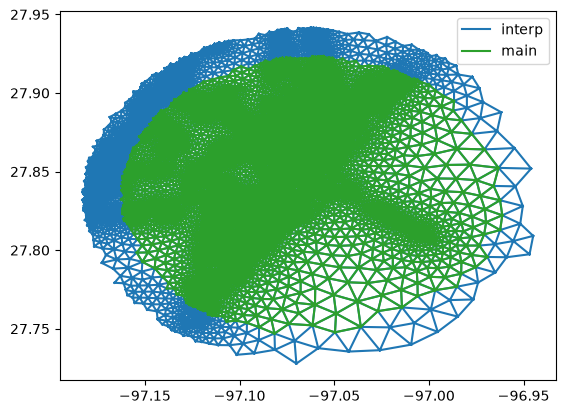

In [37]:
# Check that the interpolataion mesh has a margin around the main mesh
fig, ax = plt.subplots()
ax.triplot(triangulation_interp, label='interp')
ax.triplot(triangulation_main, label='main')
ax.legend()
fig.show()

## Project coordinates

## Create FEniCSx mesh

## Create MatPlotLib triangulation